In [1]:
import pandas as pd

from Unit5 import x_train, x_test

df = pd.DataFrame({
    "Job" : [1,1,0,1,0,0,1,0],
    "Saving" : [1,0,0,0,1,1,0,0],
    "Buycar": [1,0,1,1,1,1,0,0]
})

In [2]:
y = df["Buycar"]
x = df.drop("Buycar", axis=1)

In [3]:
from sklearn.tree import DecisionTreeClassifier,export_text,plot_tree
dt = DecisionTreeClassifier(criterion="entropy")
dt.fit(x, y)
y_pred = dt.predict(x)
print(y_pred)


[1 0 0 0 1 1 0 0]


In [4]:
tree_text = export_text(dt,feature_names=["Job","Saving"])
print(tree_text)

|--- Saving <= 0.50
|   |--- Job <= 0.50
|   |   |--- class: 0
|   |--- Job >  0.50
|   |   |--- class: 0
|--- Saving >  0.50
|   |--- class: 1



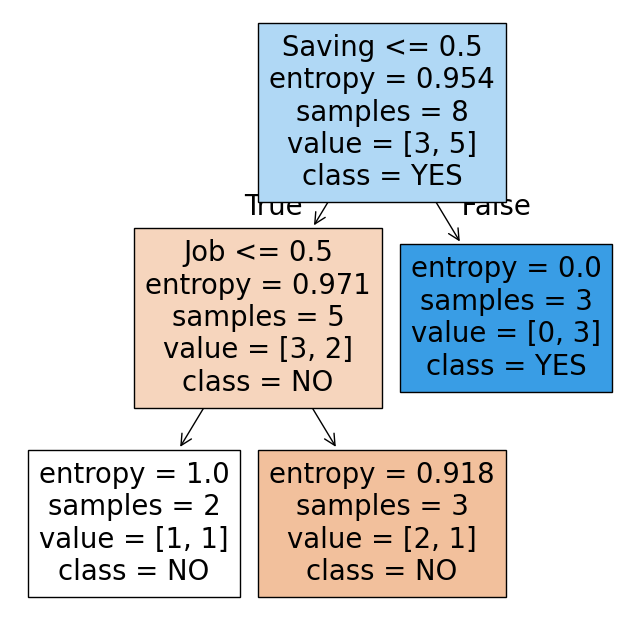

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plot_tree(dt, feature_names=["Job", "Saving"],class_names=["NO", "YES"],filled=True,max_depth=4)
plt.show()

In [6]:
df = pd.read_csv("C:\\Users\\dapat\\OneDrive\\Dhairya files\\sem4\\Python\\practice\\Python-2_26-main\\Decision Tree.csv")
df

,CGPA,Communication,Aptitute,Programming Skills,Job Offered?
0,1,1,1,1,1
1,2,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,1,1,1,0,1
5,1,1,1,1,1
6,2,0,0,0,0
7,2,0,0,1,0
8,1,0,1,1,1
9,2,1,1,1,1


In [7]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8     False
9      True
10    False
11     True
12    False
13    False
14    False
15    False
16     True
17     True
dtype: bool

In [8]:
 y = df["Job Offered?"]
 x = df.drop("Job Offered?", axis=1)

In [9]:
dt = DecisionTreeClassifier(criterion="entropy")
dt.fit(x, y)
y_pred = dt.predict(x)

In [10]:
tree_text = export_text(dt,feature_names=["CGPA","Communication","Aptitude","Programming Skills"])
print(tree_text)

|--- Aptitude <= 0.50
|   |--- class: 0
|--- Aptitude >  0.50
|   |--- Communication <= 0.50
|   |   |--- Programming Skills <= 0.50
|   |   |   |--- class: 0
|   |   |--- Programming Skills >  0.50
|   |   |   |--- CGPA <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- CGPA >  1.50
|   |   |   |   |--- class: 0
|   |--- Communication >  0.50
|   |   |--- class: 1



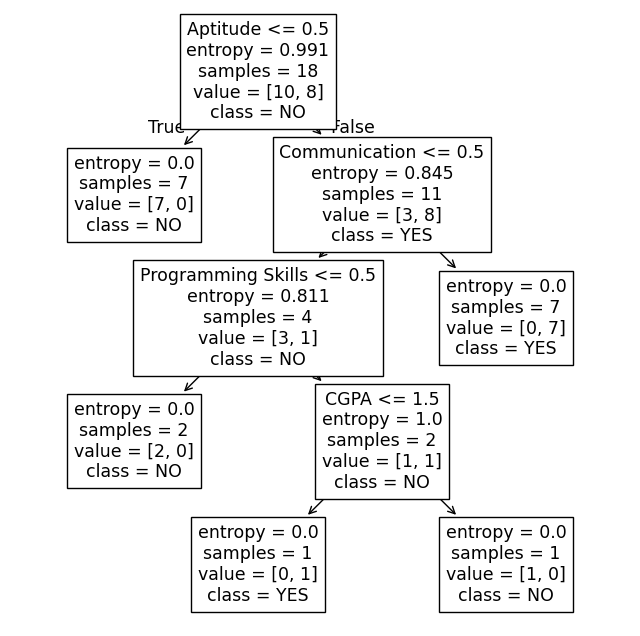

In [11]:
plt.figure(figsize=(8,8))
plot_tree(dt,feature_names=["CGPA","Communication","Aptitude","Programming Skills"],class_names=["NO", "YES"])
plt.show()

In [12]:
y_pred = dt.predict(x)
print(y_pred)

[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 1]


In [13]:
from sklearn.metrics import accuracy_score,recall_score
print("Accuracy:",accuracy_score(y,y_pred))
print("Recall:",recall_score(y,y_pred))

Accuracy: 1.0
Recall: 1.0


In [14]:
print(dt.predict([[2,1,1,1]]))

[1]


c:\Users\dapat\OneDrive\Dhairya files\sem4\Python\practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [15]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
df = pd.read_csv("C:\\Users\\dapat\\OneDrive\\Dhairya files\\sem4\\Python\\practice\\Python-2_26-main\\PlayTennis.csv")
df

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [16]:
print(df["play"].unique())
print(df["play"].dtype)

<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
str


In [17]:
df["outlook"] = df["outlook"].replace({"sunny":0,"rainy":2,"overcast":1})
df["temp"] = df["temp"].replace({"hot":0,"mild":1,"cool":2})
df["humidity"] = df["humidity"].replace({"normal":0,"high":1})
df["windy"] = df["windy"].replace({False:0,True:1})
df["play"] = df["play"].replace({"no":0,"yes":1})

In [18]:
df

,outlook,temp,humidity,windy,play
0,0,0,1,0,0
1,0,0,1,1,0
2,1,0,1,0,1
3,2,1,1,0,1
4,2,2,0,0,1
5,2,2,0,1,0
6,1,2,0,1,1
7,0,1,1,0,0
8,0,2,0,0,1
9,2,1,0,0,1


In [22]:
df = df.dropna()
Y1 = df["play"].astype(int)
X1 = df.drop("play", axis=1)
dt = DecisionTreeClassifier(criterion="entropy")
dt.fit(X1, Y1)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [ ]:
Y1

0     0
1     0
2     1
3     1
4     1
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    0
Name: play, dtype: object

In [55]:
from sklearn.datasets import load_diabetes
df = load_diabetes()
df

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [56]:

df_x = pd.DataFrame(df['data'])
df_x

,0,1,2,3,4,5,6,7,8,9
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [57]:
df_y = pd.DataFrame(df['target'])
df_y

,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


For the given dataset find the optimum accuracy and suggest which model tom be used

In [59]:
d_featurename = df['feature_names']
d_featurename

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [62]:
df_x = pd.DataFrame(df['data'],columns=d_featurename)
df_x

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [61]:
df_y = pd.DataFrame(df['target'])
df_y

,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
x_train,x_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=20)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
print(y_pred)

[ 31.  91. 150.  49.  67.  53. 191.  69.  68.  66. 150.  47. 101.  78.
  91.  85. 150. 178.  49.  59.  49.  48.  47.  31.  66.  42.  74.  66.
  70.  95. 129.  77.  59.  51.  95. 275.  59.  53.  40.  81.  42.  52.
 127. 138. 110. 147.  78. 121.  49. 214.  67.  80.  65. 180.  88. 103.
  64.  71.  77.  48.  37. 174. 122. 245. 107.  49.  91.  42.  59.  48.
 225.  37. 129.  42.  31.  88.  51.  99. 101.  52. 178. 191.  91.  39.
  39.  83.  61.  67.  47.]


C:\Users\dapat\OneDrive\Dhairya files\sem4\Python\practice\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\dapat\OneDrive\Dhairya files\sem4\Python\practice\.venv\Lib\site-packages\sklearn\neighbors\_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


In [67]:
from sklearn.metrics import accuracy_score,recall_score
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.011235955056179775


In [68]:
y_pred_train = knn.predict(x_train)
print(accuracy_score(y_train,y_pred_train))

0.17847025495750707


In [74]:
li = []
for i in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    li.append(accuracy_score(y_test,y_pred))
print(li)

[0.011235955056179775, 0.011235955056179775, 0.011235955056179775, 0.011235955056179775, 0.011235955056179775, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


C:\Users\dapat\OneDrive\Dhairya files\sem4\Python\practice\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\dapat\OneDrive\Dhairya files\sem4\Python\practice\.venv\Lib\site-packages\sklearn\neighbors\_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
C:\Users\dapat\OneDrive\Dhairya files\sem4\Python\practice\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\dapat\OneDrive\Dhairya files\sem4\Python\practice\.venv\Lib\site-package

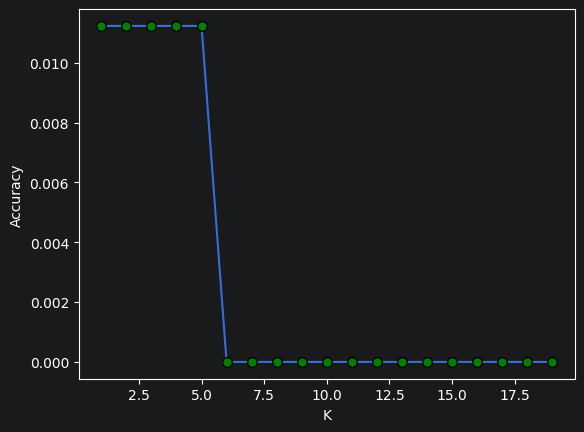

In [75]:
from matplotlib import pyplot as plt
plt.plot(range(1,20),li,ms =7, mec = 'k', mfc = 'g',marker = 'o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [97]:
from sklearn.tree import DecisionTreeClassifier,export_text,plot_tree
dt = DecisionTreeClassifier(criterion="entropy",random_state=20)
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)

C:\Users\dapat\OneDrive\Dhairya files\sem4\Python\practice\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


In [98]:
tree_text = export_text(dt,feature_names=d_featurename,)
print(tree_text)

|--- bmi <= -0.00
|   |--- age <= -0.00
|   |   |--- bmi <= -0.04
|   |   |   |--- age <= -0.06
|   |   |   |   |--- s1 <= -0.05
|   |   |   |   |   |--- bmi <= -0.06
|   |   |   |   |   |   |--- s4 <= -0.06
|   |   |   |   |   |   |   |--- s6 <= -0.01
|   |   |   |   |   |   |   |   |--- class: 85.0
|   |   |   |   |   |   |   |--- s6 >  -0.01
|   |   |   |   |   |   |   |   |--- class: 137.0
|   |   |   |   |   |   |--- s4 >  -0.06
|   |   |   |   |   |   |   |--- s6 <= -0.04
|   |   |   |   |   |   |   |   |--- class: 101.0
|   |   |   |   |   |   |   |--- s6 >  -0.04
|   |   |   |   |   |   |   |   |--- class: 55.0
|   |   |   |   |   |--- bmi >  -0.06
|   |   |   |   |   |   |--- bp <= 0.00
|   |   |   |   |   |   |   |--- age <= -0.08
|   |   |   |   |   |   |   |   |--- class: 99.0
|   |   |   |   |   |   |   |--- age >  -0.08
|   |   |   |   |   |   |   |   |--- class: 143.0
|   |   |   |   |   |   |--- bp >  0.00
|   |   |   |   |   |   |   |--- class: 86.0
|   |   |   |   |--

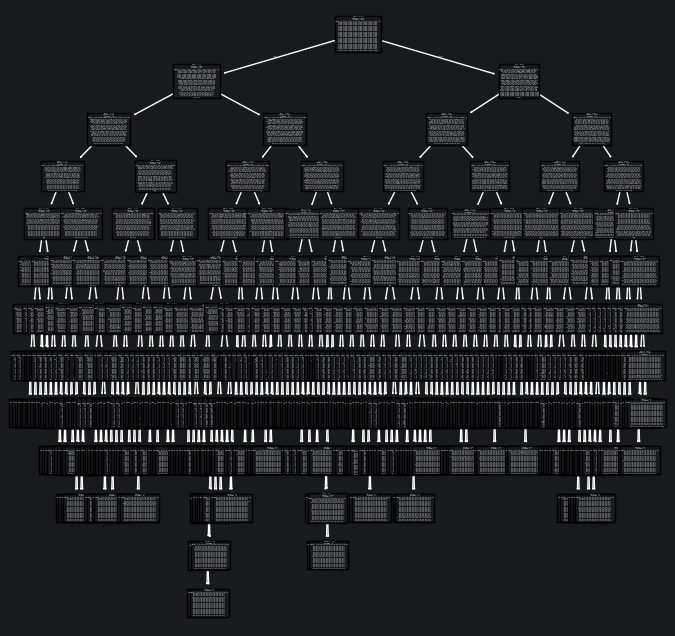

In [99]:
plt.figure(figsize=(8,8))
plot_tree(dt,feature_names=d_featurename)
plt.show()

In [90]:
dt.get_depth()

10

In [91]:
dt.get_n_leaves()

np.int64(317)

In [101]:
from sklearn.metrics import accuracy_score,recall_score
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

Accuracy: 0.011235955056179775


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [104]:
from sklearn.tree import DecisionTreeClassifier,export_text,plot_tree
dt = DecisionTreeClassifier(criterion="entropy",random_state=20,max_depth=6 )
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)

C:\Users\dapat\OneDrive\Dhairya files\sem4\Python\practice\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


In [105]:
tree_text = export_text(dt,feature_names=d_featurename,)
print(tree_text)

|--- s5 <= -0.00
|   |--- age <= -0.00
|   |   |--- s6 <= -0.04
|   |   |   |--- bmi <= -0.04
|   |   |   |   |--- age <= -0.06
|   |   |   |   |   |--- s2 <= -0.04
|   |   |   |   |   |   |--- class: 99.0
|   |   |   |   |   |--- s2 >  -0.04
|   |   |   |   |   |   |--- class: 51.0
|   |   |   |   |--- age >  -0.06
|   |   |   |   |   |--- age <= -0.05
|   |   |   |   |   |   |--- class: 72.0
|   |   |   |   |   |--- age >  -0.05
|   |   |   |   |   |   |--- class: 63.0
|   |   |   |--- bmi >  -0.04
|   |   |   |   |--- s1 <= -0.04
|   |   |   |   |   |--- s6 <= -0.07
|   |   |   |   |   |   |--- class: 97.0
|   |   |   |   |   |--- s6 >  -0.07
|   |   |   |   |   |   |--- class: 71.0
|   |   |   |   |--- s1 >  -0.04
|   |   |   |   |   |--- bmi <= -0.02
|   |   |   |   |   |   |--- class: 52.0
|   |   |   |   |   |--- bmi >  -0.02
|   |   |   |   |   |   |--- class: 103.0
|   |   |--- s6 >  -0.04
|   |   |   |--- age <= -0.04
|   |   |   |   |--- s1 <= -0.05
|   |   |   |   |   |--- 

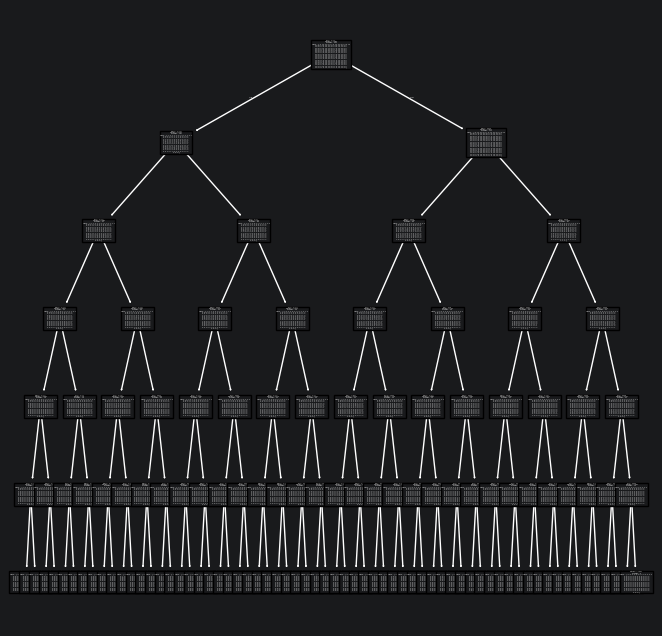

In [106]:
plt.figure(figsize=(8,8))
plot_tree(dt,feature_names=d_featurename)
plt.show()

In [107]:
print("depth:",dt.get_depth())
print("n_leaves:",dt.get_n_leaves())

depth: 6
n_leaves: 64


In [108]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.0


In [109]:
y_pred_train = dt.predict(x_train)
print(accuracy_score(y_train,y_pred_train))

0.2747875354107649
